In [20]:
# Imports
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Configuration
DATA_PATH = "../Data/Scores"
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 20

In [4]:
# Load Dataset
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.endswith((".png", ".jpg", ".jpeg")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4297 samples, 34 classes


In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)
print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Train: (3437, 128, 128, 3), Test: (860, 128, 128, 3)


In [7]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)

In [9]:
# Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_map), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,026 (12.62 MB)

 Trainable params: 3,309,026 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train Model
print("[INFO] Training CNN...")
history = model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    verbose=1
)

[INFO] Training CNN...


/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
  1/215 ━━━━━━━━━━━━━━━━━━━━ 5:45 2s/step - accuracy: 0.0625 - loss: 3.5076

2025-10-10 12:17:53.944721: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32514048 exceeds 10% of free system memory.
2025-10-10 12:17:54.065521: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25719552 exceeds 10% of free system memory.
2025-10-10 12:17:54.102425: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32514048 exceeds 10% of free system memory.
2025-10-10 12:17:54.139843: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32514048 exceeds 10% of free system memory.


  2/215 ━━━━━━━━━━━━━━━━━━━━ 38s 183ms/step - accuracy: 0.0625 - loss: 3.7478

2025-10-10 12:17:54.242870: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25719552 exceeds 10% of free system memory.


215/215 ━━━━━━━━━━━━━━━━━━━━ 68s 310ms/step - accuracy: 0.1189 - loss: 2.9612 - val_accuracy: 0.4605 - val_loss: 2.0433
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 36s 167ms/step - accuracy: 0.3965 - loss: 2.1175 - val_accuracy: 0.7221 - val_loss: 1.2201
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 36s 168ms/step - accuracy: 0.5773 - loss: 1.5241 - val_accuracy: 0.7477 - val_loss: 0.9927
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 35s 165ms/step - accuracy: 0.6302 - loss: 1.2913 - val_accuracy: 0.7535 - val_loss: 0.9567
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 189ms/step - accuracy: 0.6877 - loss: 1.0784 - val_accuracy: 0.7605 - val_loss: 0.9203
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 40s 185ms/step - accuracy: 0.6958 - loss: 1.0790 - val_accuracy: 0.7593 - val_loss: 0.9009
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.7037 - loss: 0.9891 - val_accuracy: 0.7605 - val_loss: 0.8878
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 39s 183ms/step - accuracy: 0.7093 - loss: 0.9608 - val

In [13]:
# Classification report
# Get unique labels in y_true
unique_labels = np.unique(y_true)  # e.g., array([0,1,...,26])

# Trim class_names to match actual labels
target_names = [class_names[i] for i in unique_labels]

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_classes,
    labels=unique_labels,
    target_names=target_names,
    zero_division=0
))


Classification Report:
                      precision    recall  f1-score   support

          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.92      0.95      0.93       119
              Star_3       0.67      0.11      0.18        19
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.52      0.96      0.68        50
              Star_5       0.67      0.08      0.15        24
              Wave_3       0.00      0.00      0.00        22
              Wave_2       0.00      0.00      0.00         3
              Wave_4       0.79      0.97      0.87       103
            Circle_3       0.00      0.00      0.00        15
            Circle_4       0.86      0.98      0.91        91
            Square_0       0.00      0.00      0.00         1
            Square_4       0.00      0.00      0.00        10
            Square_5       0.90      0.98    

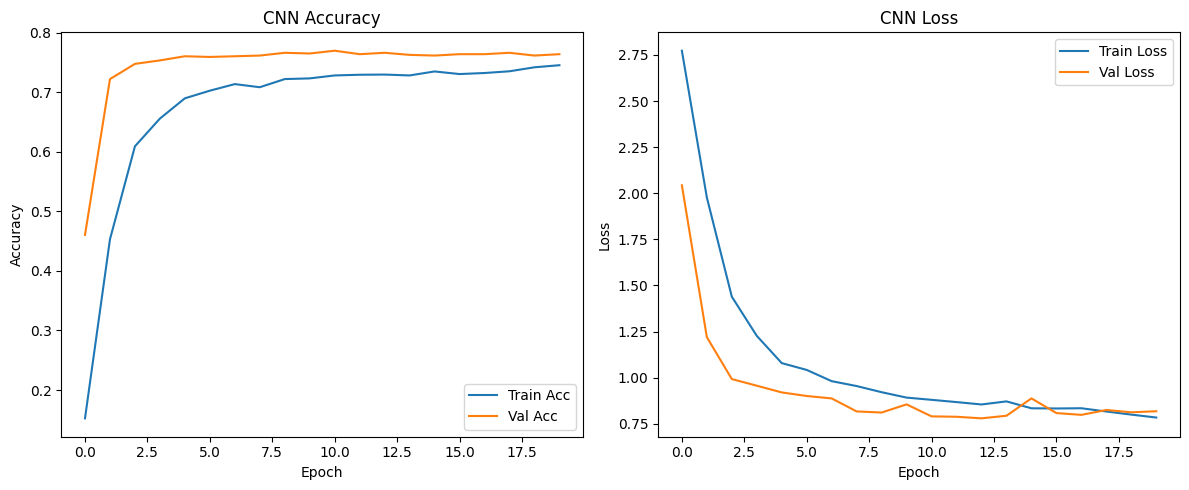

In [14]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Save Model
SAVE_DIR = "./model_outputs/CNN"
os.makedirs(SAVE_DIR, exist_ok=True)

In [16]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy (CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [17]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss (CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [18]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "CNN_model.h5"))
print("[INFO] Model saved successfully")

[INFO] Model saved successfully


In [21]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_CNN.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

[INFO] Training history saved as JSON


In [22]:
# Save
pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "CNN_training_history.csv"), index=False)

In [23]:
# Convert to DataFrame
report_dict = classification_report(
    y_true, 
    y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save Classification report
report_path = os.path.join(SAVE_DIR, "CNN_classification_report.csv")
report_df.to_csv(report_path, index=True)

print("[INFO] Save Classification report as CSV")

[INFO] Save Classification report as CSV
